# Last-7-Day Patient Classification — 32/64/128-dim × 7 Days Features

**Goal**: Classify label 0 vs label 1 using the full 7-day history per patient.
Runs for embed_dim ∈ {32, 64, 128} — each produces a separate result set.

**Approach**:
```
Day 0 embedding [D-dim] \
Day 1 embedding [D-dim]  \
Day 2 embedding [D-dim]   → concatenate → [7D-dim] → LR/SVM/DT/RF/XGB → label 0/1
...                        /
Day 6 embedding [D-dim] /
```

Each patient = one 7D-dim feature vector. Missing days → zero-padded.
Train/val/test split at patient level (no leakage).

**Models**: LR, SVM, DT, RF (fine-tuned), XGBoost (fine-tuned).

**Save folders**:
- `daily_embedding_classifier_last7days_32dim/classifier_results/`
- `daily_embedding_classifier_last7days_64dim/classifier_results/`
- `daily_embedding_classifier_last7days_128dim/classifier_results/`


---
## Step 1 — Install & Import

In [1]:
!pip install -q xgboost scikit-learn imbalanced-learn tqdm


In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from tqdm.auto import tqdm
from matplotlib.colors import LinearSegmentedColormap
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, make_scorer
)
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, LeaveOneGroupOut, cross_val_score
)
from scipy.stats import randint, uniform
import xgboost as xgb

print('All imports OK')


All imports OK


---
## Step 2 — Mount Drive & Set Embedding Paths

Embeddings for each dim are loaded inside the main loop (Step 3+).
Set `BASE_MODEL_DIR` to the folder containing your dim subfolders.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# ── Folder structure ─────────────────────────────────────────────────────────
# Best_Model/
#   daily_embedding_classifier_last7days_32dim/   ← transformer embeddings
#   daily_embedding_classifier_last7days_64dim/
#   daily_embedding_classifier_last7days_128dim/
#   5models/                                       ← NEW: classifier models
#     last7days/
#       32dim/
#         xgboost/         model.joblib + best_params.json + metrics.json
#         logistic_regression/
#         random_forest/
#         svm/
#         decision_tree/
#         pca_xgboost/
#       64dim/  ...
#       128dim/ ...

BASE_MODEL_DIR  = "/content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model"
MODELS_ROOT     = os.path.join(BASE_MODEL_DIR, '5models', 'last7days')
ALL_DAYS        = list(range(7))   # 0..6
EMBED_DIMS      = [32, 64, 128]

# Pre-create all dim + model subfolders
MODEL_NAMES = ['xgboost', 'logistic_regression', 'random_forest',
               'svm', 'decision_tree', 'pca_xgboost']
for dim in EMBED_DIMS:
    for mname in MODEL_NAMES:
        os.makedirs(os.path.join(MODELS_ROOT, f'{dim}dim', mname), exist_ok=True)

print(f'Base model dir : {BASE_MODEL_DIR}')
print(f'Models root    : {MODELS_ROOT}')
print(f'Embed dims     : {EMBED_DIMS}')
print(f'\nFolder structure created:')
for dim in EMBED_DIMS:
    for mname in MODEL_NAMES:
        print(f'  5models/last7days/{dim}dim/{mname}/')


Mounted at /content/drive
Base model dir : /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model
Models root    : /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/5models/last7days
Embed dims     : [32, 64, 128]

Folder structure created:
  5models/last7days/32dim/xgboost/
  5models/last7days/32dim/logistic_regression/
  5models/last7days/32dim/random_forest/
  5models/last7days/32dim/svm/
  5models/last7days/32dim/decision_tree/
  5models/last7days/32dim/pca_xgboost/
  5models/last7days/64dim/xgboost/
  5models/last7days/64dim/logistic_regression/
  5models/last7days/64dim/random_forest/
  5models/last7days/64dim/svm/
  5models/last7days/64dim/decision_tree/
  5models/last7days/64dim/pca_xgboost/
  5models/last7days/128dim/xgboost/
  5models/last7days/128dim/logistic_regression/
  5models/last7days/128dim/random_forest/
  5models/last7days/128dim/svm/
  5models/last7days/128dim/decision_tree/
  5models/last7days/128dim/pca_xgboost/


---
## Step 3 — Evaluation Helpers (shared across all dims)

Define `build_patient_features`, `plot_cm`, and `evaluate` once.
The main training loop (Step 4) calls these for each embed_dim.


In [4]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, make_scorer
)
from matplotlib.colors import LinearSegmentedColormap

f1_scorer = make_scorer(f1_score, pos_label=1, zero_division=0)
CV        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
LABELS    = ['Label 0 (healthy)', 'Label 1 (hospital)']
blue_cmap = LinearSegmentedColormap.from_list(
    'blue_cm', ['#EBF5FB', '#1A5276'], N=256)


def build_patient_features(emb_df, emb_cols, emb_dim):
    """
    One row per patient = concatenated embeddings for days 0..6.
    Missing days → zero-padded.
    Returns X [n_patients, 7*emb_dim], y [n_patients], patient_ids.
    """
    patient_ids = emb_df['patient_id'].unique()
    X_rows, y_rows, pids_out = [], [], []
    for pid in patient_ids:
        sub   = emb_df[emb_df['patient_id'] == pid]
        label = int(sub['label'].iloc[0])
        day_vecs = []
        for d in ALL_DAYS:
            rows = sub[sub['unified_day'] == d]
            if len(rows) > 0:
                vec = rows[emb_cols].values.mean(axis=0).astype(np.float32)
            else:
                vec = np.zeros(emb_dim, dtype=np.float32)
            day_vecs.append(vec)
        X_rows.append(np.concatenate(day_vecs))
        y_rows.append(label)
        pids_out.append(pid)
    return np.array(X_rows), np.array(y_rows), np.array(pids_out)


def plot_cm(ax, cm, title):
    ax.imshow(cm, interpolation='nearest', cmap=blue_cmap)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks([0,1]); ax.set_xticklabels(['Label 0','Label 1'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['Label 0','Label 1'])
    thresh = cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i,j] > thresh else '#1A5276'
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    fontsize=14, fontweight='bold', color=color)


def evaluate(clf, model_name, save_name, out_dir,
             X_tr, y_tr, pids_tr,
             X_va, y_va, pids_va,
             X_te, y_te, pids_te):
    """Evaluate on train/val/test. Returns metrics dict."""
    print('\n' + '='*60)
    print(f'{model_name} — Evaluation')
    print('='*60)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    fig.suptitle(f'{model_name} — Confusion Matrices', fontsize=12)

    metrics = {}
    for ax, (X, y, pids, split_name) in zip(axes, [
        (X_tr, y_tr, pids_tr, 'Train'),
        (X_va, y_va, pids_va, 'Val'),
        (X_te, y_te, pids_te, 'Test'),
    ]):
        try:    probs = clf.predict_proba(X)[:, 1]
        except: probs = clf.decision_function(X)
        preds = (probs >= 0.5).astype(int) if probs.min() >= 0 else clf.predict(X)
        try:    auc = roc_auc_score(y, probs)
        except: auc = float('nan')
        f1   = f1_score(y, preds, pos_label=1, zero_division=0)
        cm   = confusion_matrix(y, preds)
        acc  = accuracy_score(y, preds)
        acc0 = accuracy_score(y[y==0], preds[y==0]) if (y==0).sum()>0 else float('nan')
        acc1 = accuracy_score(y[y==1], preds[y==1]) if (y==1).sum()>0 else float('nan')

        print(f'\n── {split_name}  AUROC={auc:.4f}  F1(L1)={f1:.4f} ──')
        print(f'  Accuracy (combined): {acc:.4f}')
        print(f'  Accuracy (label 0) : {acc0:.4f}')
        print(f'  Accuracy (label 1) : {acc1:.4f}')
        print(classification_report(y, preds, target_names=LABELS, zero_division=0))
        print(f'  Confusion matrix:')
        print(f'              Pred 0   Pred 1')
        print(f'  True 0       {cm[0,0]:>5}    {cm[0,1]:>5}')
        print(f'  True 1       {cm[1,0]:>5}    {cm[1,1]:>5}')

        if split_name == 'Test':
            try:    prob_out = clf.predict_proba(X)[:, 1]
            except: prob_out = probs
            df_res = pd.DataFrame({
                'patient_id':  pids,
                'true_label':  y,
                'pred_label':  preds,
                'prob_label1': prob_out.round(3),
                'result': ['✅' if p==t else '❌' for p,t in zip(preds,y)]
            }).sort_values(['true_label','patient_id'])
            print(f'\n  Per-patient (test):')
            print(df_res.to_string(index=False))

        plot_cm(ax, cm, f'{split_name}\nAcc={acc:.3f}  F1={f1:.3f}')
        metrics[split_name] = {
            'auc':  round(auc,  4),
            'f1':   round(f1,   4),
            'acc':  round(acc,  4),
            'acc0': round(acc0, 4),
            'acc1': round(acc1, 4),
        }

    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f'cm_{save_name}.png'), dpi=120)
    plt.show()
    return metrics


print('Helpers ready: build_patient_features, plot_cm, evaluate')


Helpers ready: build_patient_features, plot_cm, evaluate


---
## Step 4 — Main Loop: Train 5 Models for each embed_dim (32 / 64 / 128)

For each dim:
1. Load embeddings from the dim's save folder
2. Build 7D-dim patient feature vectors
3. Train & fine-tune: XGBoost, LR, RF, SVM, DT
4. Run LOGO-CV on best models
5. Save confusion matrices, summary CSV, bar chart


Overall progress:   0%|          | 0/3 [00:00<?, ?dim/s]


██████████████████████████████████████████████████████████████████████
  EMBED_DIM = 32  →  feature vector = 224 dims (32×7)
██████████████████████████████████████████████████████████████████████
  Loaded: train=(325, 35)  val=(100, 35)  test=(151, 35)
  Feature vector: 224 dims (32×7)
  Train: (48, 224)  Val: (15, 224)  Test: (22, 224)
  Label1 — train=18  val=5  test=5
  ✅ No patient leakage

  ▶ XGBoost Stage 1 — RandomizedSearchCV (100 iters)...
  XGB-Random: 100 combos × 5 folds = 500 fits


  Fitting XGB-Random:   0%|          | 00:00

  ✅ Done in 21.6s  Best CV F1=0.7276
  Best params: {'colsample_bytree': np.float64(0.6956488938538636), 'gamma': np.float64(0.5494435859801283), 'learning_rate': np.float64(0.06112434258477011), 'max_depth': 4, 'min_child_weight': 7, 'n_estimators': 180, 'reg_alpha': np.float64(2.2823551458506923), 'reg_lambda': np.float64(9.419157963542444), 'subsample': np.float64(0.8854835899772805)}

  ▶ XGBoost Stage 2 — GridSearchCV (fine, ~512 combos)...
  XGB-Fine: 512 combos × 5 folds = 2560 fits


  Fitting XGB-Fine:   0%|          | 00:00

  ✅ Done in 59.5s  Best CV F1=0.2000
  Best params: {'colsample_bytree': 0.5, 'gamma': 0.5, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 100, 'reg_alpha': 1.0, 'reg_lambda': 8, 'subsample': 0.7}
  Using: random XGBoost

XGBoost (dim=32) — Evaluation

── Train  AUROC=0.8815  F1(L1)=0.7778 ──
  Accuracy (combined): 0.8333
  Accuracy (label 0) : 0.8667
  Accuracy (label 1) : 0.7778
                    precision    recall  f1-score   support

 Label 0 (healthy)       0.87      0.87      0.87        30
Label 1 (hospital)       0.78      0.78      0.78        18

          accuracy                           0.83        48
         macro avg       0.82      0.82      0.82        48
      weighted avg       0.83      0.83      0.83        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          26        4
  True 1           4       14

── Val  AUROC=0.9800  F1(L1)=0.8000 ──
  Accuracy (combined): 0.8667
  Accuracy (label 0) : 0.9000
  Accuracy 

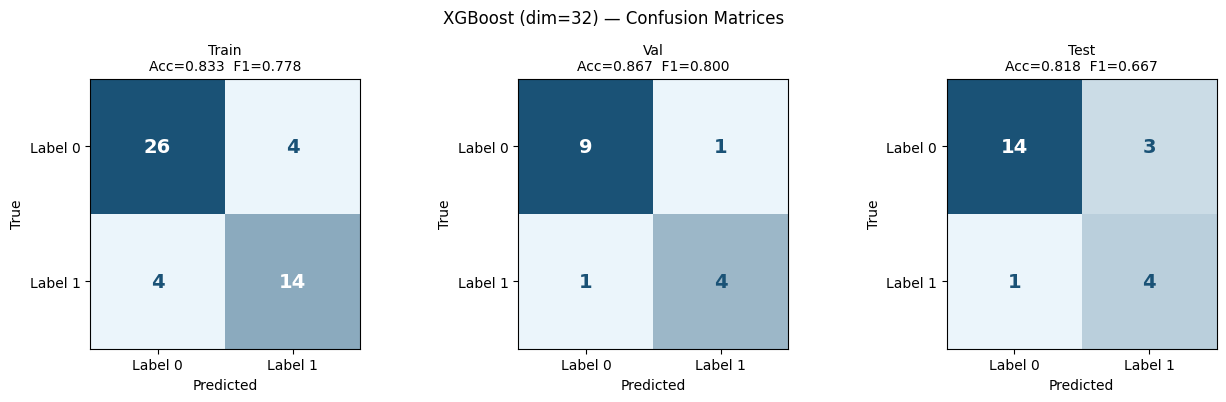


  ▶ Logistic Regression GridSearchCV (6 combos)...
  LR: 6 combos × 5 folds = 30 fits


  Fitting LR:   0%|          | 00:00

  ✅ Done in 0.3s  Best CV F1=0.7539
  Best params: {'clf__C': 0.001, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}

Logistic Regression (dim=32) — Evaluation

── Train  AUROC=0.8444  F1(L1)=0.7568 ──
  Accuracy (combined): 0.8125
  Accuracy (label 0) : 0.8333
  Accuracy (label 1) : 0.7778
                    precision    recall  f1-score   support

 Label 0 (healthy)       0.86      0.83      0.85        30
Label 1 (hospital)       0.74      0.78      0.76        18

          accuracy                           0.81        48
         macro avg       0.80      0.81      0.80        48
      weighted avg       0.82      0.81      0.81        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          25        5
  True 1           4       14

── Val  AUROC=0.9600  F1(L1)=0.8333 ──
  Accuracy (combined): 0.8667
  Accuracy (label 0) : 0.8000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      0.80      0

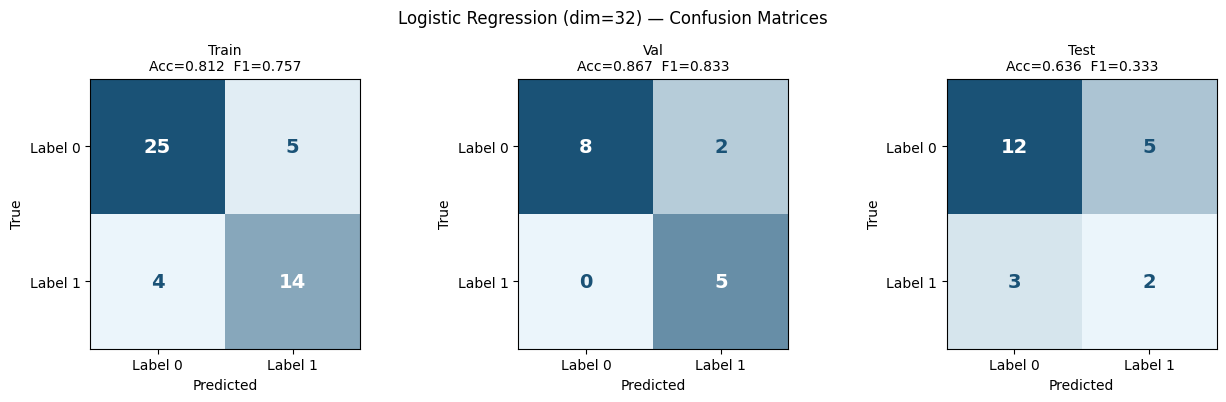


  ▶ Random Forest RandomizedSearchCV (100 iters)...
  RF-Random: 100 combos × 5 folds = 500 fits


  Fitting RF-Random:   0%|          | 00:00

  ✅ Done in 283.9s  Best CV F1=0.7770
  Best params: {'max_depth': None, 'max_features': 0.3, 'max_samples': np.float64(0.8566223936114975), 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 317}

Random Forest (dim=32) — Evaluation

── Train  AUROC=1.0000  F1(L1)=0.9714 ──
  Accuracy (combined): 0.9792
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 0.9444
                    precision    recall  f1-score   support

 Label 0 (healthy)       0.97      1.00      0.98        30
Label 1 (hospital)       1.00      0.94      0.97        18

          accuracy                           0.98        48
         macro avg       0.98      0.97      0.98        48
      weighted avg       0.98      0.98      0.98        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          30        0
  True 1           1       17

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                   

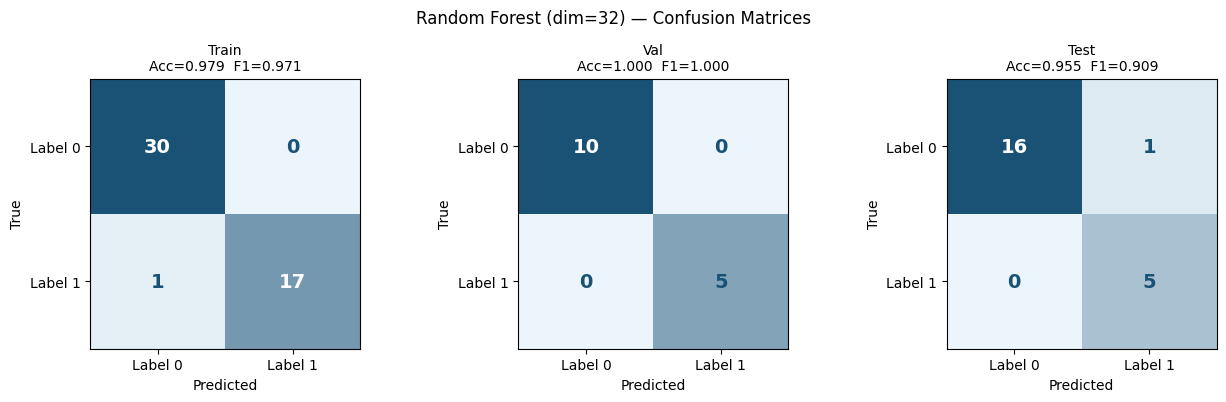


  ▶ SVM GridSearchCV (12 combos)...
  SVM: 12 combos × 5 folds = 60 fits


  Fitting SVM:   0%|          | 00:00

  ✅ Done in 0.5s  Best CV F1=0.7792
  Best params: {'clf__C': 1.0, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}

SVM (dim=32) — Evaluation

── Train  AUROC=0.9426  F1(L1)=0.8824 ──
  Accuracy (combined): 0.9167
  Accuracy (label 0) : 0.9667
  Accuracy (label 1) : 0.8333
                    precision    recall  f1-score   support

 Label 0 (healthy)       0.91      0.97      0.94        30
Label 1 (hospital)       0.94      0.83      0.88        18

          accuracy                           0.92        48
         macro avg       0.92      0.90      0.91        48
      weighted avg       0.92      0.92      0.92        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          29        1
  True 1           3       15

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00      1.00        10
Label

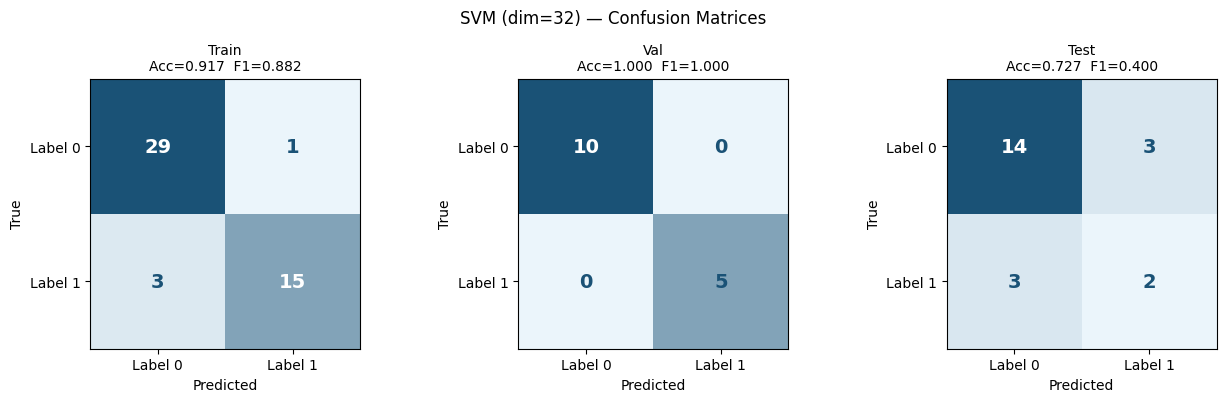


  ▶ Decision Tree GridSearchCV (24 combos)...
  DT: 24 combos × 5 folds = 120 fits


  Fitting DT:   0%|          | 00:00

  ✅ Done in 0.4s  Best CV F1=0.7000
  Best params: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 5}

Decision Tree (dim=32) — Evaluation

── Train  AUROC=0.9852  F1(L1)=0.8889 ──
  Accuracy (combined): 0.9167
  Accuracy (label 0) : 0.9333
  Accuracy (label 1) : 0.8889
                    precision    recall  f1-score   support

 Label 0 (healthy)       0.93      0.93      0.93        30
Label 1 (hospital)       0.89      0.89      0.89        18

          accuracy                           0.92        48
         macro avg       0.91      0.91      0.91        48
      weighted avg       0.92      0.92      0.92        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          28        2
  True 1           2       16

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support



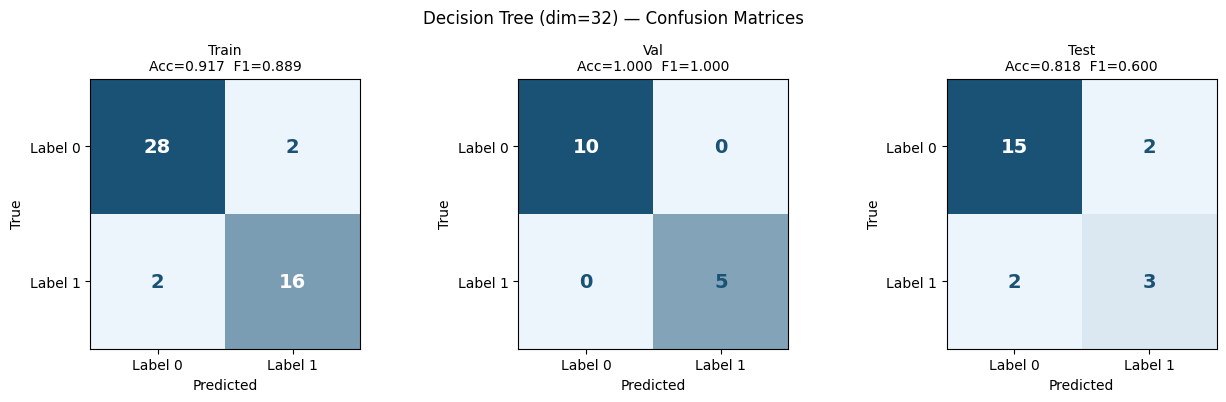


  ▶ PCA + XGBoost GridSearchCV (128 combos)...
  PCA+XGB: 128 combos × 5 folds = 640 fits


  Fitting PCA+XGB:   0%|          | 00:00

  ✅ Done in 13.5s  Best CV F1=0.7097
  Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__min_child_weight': 5, 'clf__n_estimators': 100, 'clf__reg_alpha': 0.5, 'clf__reg_lambda': 5, 'pca__n_components': 10}

PCA+XGBoost (dim=32) — Evaluation

── Train  AUROC=0.9389  F1(L1)=0.8125 ──
  Accuracy (combined): 0.8750
  Accuracy (label 0) : 0.9667
  Accuracy (label 1) : 0.7222
                    precision    recall  f1-score   support

 Label 0 (healthy)       0.85      0.97      0.91        30
Label 1 (hospital)       0.93      0.72      0.81        18

          accuracy                           0.88        48
         macro avg       0.89      0.84      0.86        48
      weighted avg       0.88      0.88      0.87        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          29        1
  True 1           5       13

── Val  AUROC=1.0000  F1(L1)=0.9091 ──
  Accuracy (combined): 0.9333
  Accuracy (label 0) : 0.9000
  Accuracy (label 1) : 1.0000
    

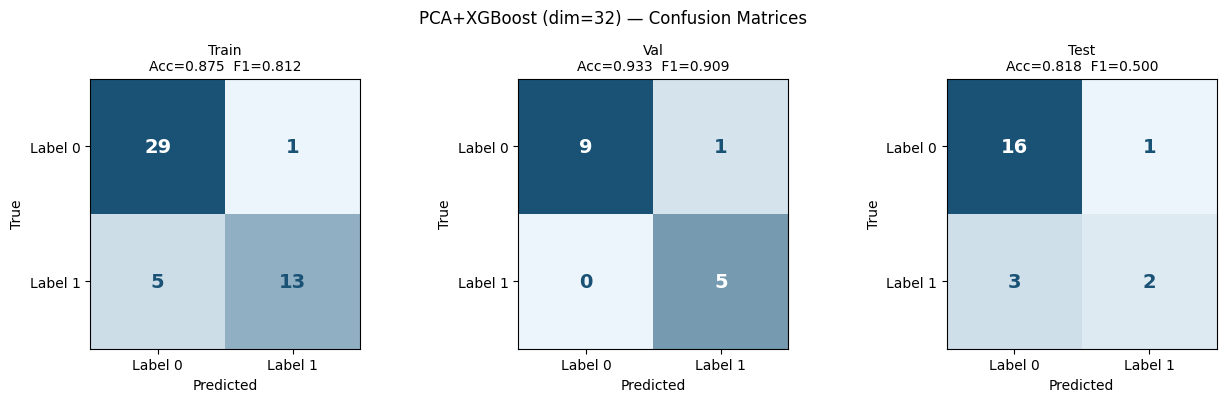

  ✅ Models captured for dim=32 → Step 5 can now save them

  ▶ Leave-One-Patient-Out CV...


  LOGO-CV:   0%|          | 0/6 [00:00<?, ?it/s]

  XGBoost          LOGO F1: 0.2353 ± 0.4242  min=0.000  max=1.000  (4.8s)
  LR               LOGO F1: 0.2353 ± 0.4242  min=0.000  max=1.000  (0.6s)
  RF               LOGO F1: 0.2824 ± 0.4501  min=0.000  max=1.000  (67.5s)
  SVM              LOGO F1: 0.2353 ± 0.4242  min=0.000  max=1.000  (0.7s)
  DT               LOGO F1: 0.2941 ± 0.4556  min=0.000  max=1.000  (0.3s)
  PCA+XGBoost      LOGO F1: 0.2000 ± 0.4000  min=0.000  max=1.000  (1.6s)

  ACCURACY TABLE — dim=32  Train
Metric                  LR         SVM          DT          RF     XGBoost PCA+XGBoost
-----------------------------------------------------------------
Accuracy            0.8125      0.9167      0.9167      0.9792      0.8333      0.8750
Acc L0              0.8333      0.9667      0.9333      1.0000      0.8667      0.9667
Acc L1              0.7778      0.8333      0.8889      0.9444      0.7778      0.7222
F1 (L1)             0.7568      0.8824      0.8889      0.9714      0.7778      0.8125
AUROC               

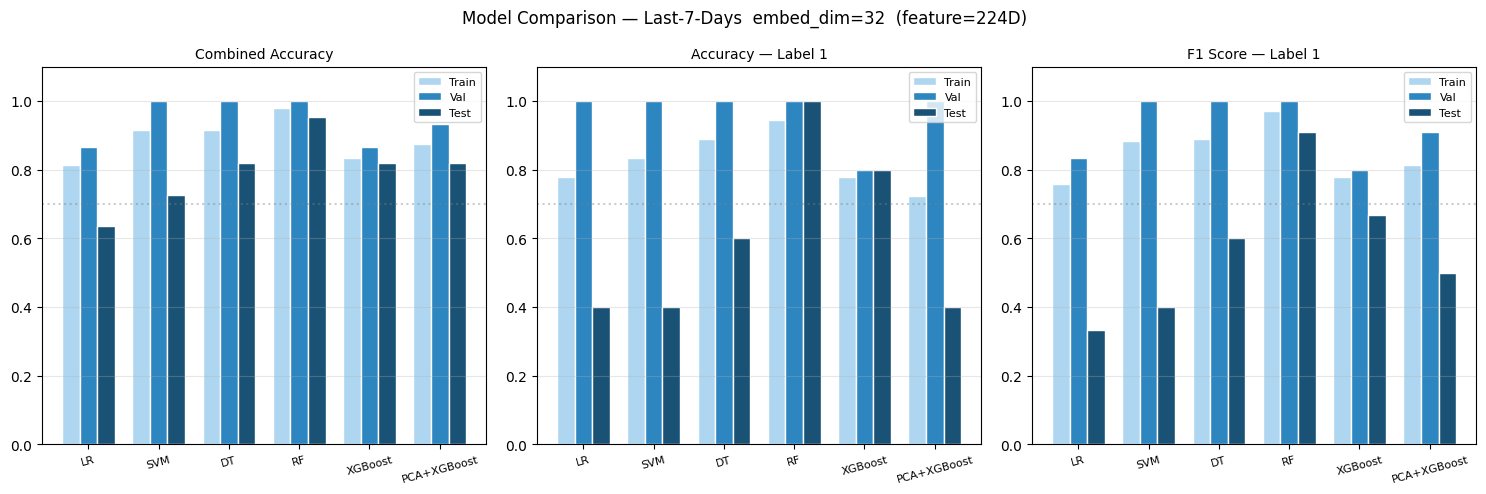


  ✅ Best model (dim=32) by val F1: SVM
     Val F1=1.0000  LOGO F1=0.2353  Total time: 7.7 min

██████████████████████████████████████████████████████████████████████
  EMBED_DIM = 64  →  feature vector = 448 dims (64×7)
██████████████████████████████████████████████████████████████████████
  Loaded: train=(325, 67)  val=(100, 67)  test=(151, 67)
  Feature vector: 448 dims (64×7)
  Train: (48, 448)  Val: (15, 448)  Test: (22, 448)
  Label1 — train=18  val=5  test=5
  ✅ No patient leakage

  ▶ XGBoost Stage 1 — RandomizedSearchCV (100 iters)...
  XGB-Random: 100 combos × 5 folds = 500 fits


  Fitting XGB-Random:   0%|          | 00:00

  ✅ Done in 26.5s  Best CV F1=0.8732
  Best params: {'colsample_bytree': np.float64(0.8248236953387058), 'gamma': np.float64(0.4946962034863953), 'learning_rate': np.float64(0.050054413531009354), 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 100, 'reg_alpha': np.float64(0.8241953910777263), 'reg_lambda': np.float64(4.108414735120847), 'subsample': np.float64(0.9391103337395961)}

  ▶ XGBoost Stage 2 — GridSearchCV (fine, ~512 combos)...
  XGB-Fine: 512 combos × 5 folds = 2560 fits


  Fitting XGB-Fine:   0%|          | 00:00

  ✅ Done in 84.0s  Best CV F1=0.2000
  Best params: {'colsample_bytree': 0.5, 'gamma': 0.5, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 100, 'reg_alpha': 1.0, 'reg_lambda': 8, 'subsample': 0.7}
  Using: random XGBoost

XGBoost (dim=64) — Evaluation

── Train  AUROC=1.0000  F1(L1)=0.9730 ──
  Accuracy (combined): 0.9792
  Accuracy (label 0) : 0.9667
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      0.97      0.98        30
Label 1 (hospital)       0.95      1.00      0.97        18

          accuracy                           0.98        48
         macro avg       0.97      0.98      0.98        48
      weighted avg       0.98      0.98      0.98        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          29        1
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=0.9091 ──
  Accuracy (combined): 0.9333
  Accuracy (label 0) : 0.9000
  Accuracy 

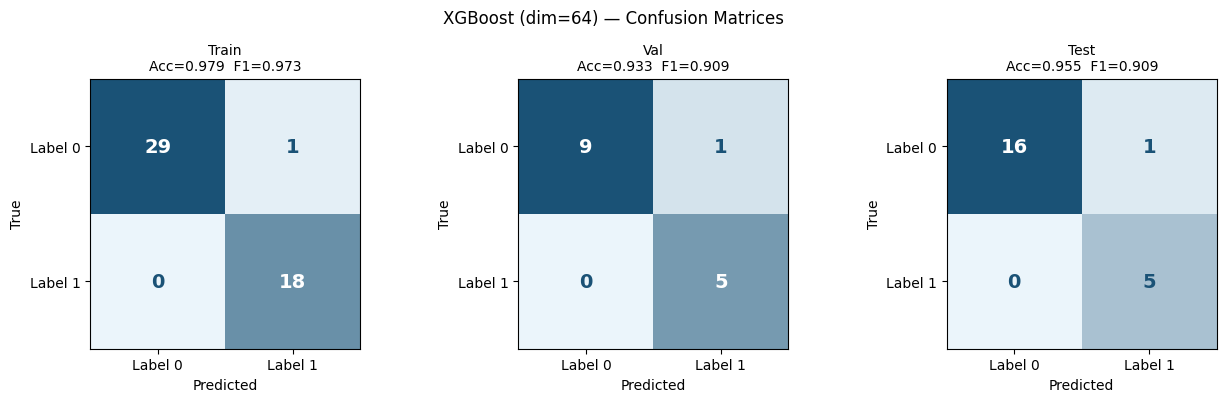


  ▶ Logistic Regression GridSearchCV (6 combos)...
  LR: 6 combos × 5 folds = 30 fits


  Fitting LR:   0%|          | 00:00

  ✅ Done in 0.3s  Best CV F1=0.9492
  Best params: {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}

Logistic Regression (dim=64) — Evaluation

── Train  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00      1.00        30
Label 1 (hospital)       1.00      1.00      1.00        18

          accuracy                           1.00        48
         macro avg       1.00      1.00      1.00        48
      weighted avg       1.00      1.00      1.00        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          30        0
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00     

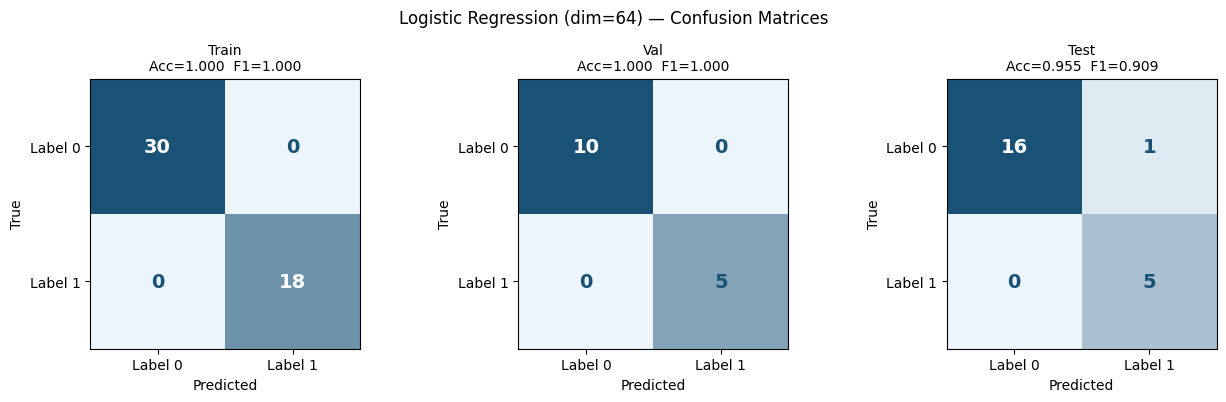


  ▶ Random Forest RandomizedSearchCV (100 iters)...
  RF-Random: 100 combos × 5 folds = 500 fits


  Fitting RF-Random:   0%|          | 00:00

  ✅ Done in 289.0s  Best CV F1=0.9051
  Best params: {'max_depth': None, 'max_features': 0.5, 'max_samples': np.float64(0.5115312125207079), 'min_samples_leaf': 11, 'min_samples_split': 11, 'n_estimators': 287}

Random Forest (dim=64) — Evaluation

── Train  AUROC=0.9704  F1(L1)=0.9000 ──
  Accuracy (combined): 0.9167
  Accuracy (label 0) : 0.8667
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      0.87      0.93        30
Label 1 (hospital)       0.82      1.00      0.90        18

          accuracy                           0.92        48
         macro avg       0.91      0.93      0.91        48
      weighted avg       0.93      0.92      0.92        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          26        4
  True 1           0       18

── Val  AUROC=0.9600  F1(L1)=0.9091 ──
  Accuracy (combined): 0.9333
  Accuracy (label 0) : 0.9000
  Accuracy (label 1) : 1.0000
                 

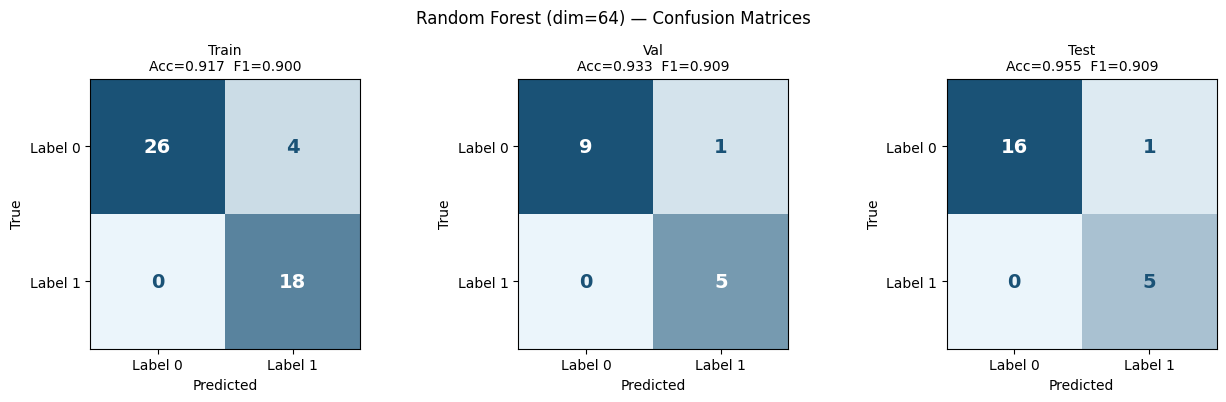


  ▶ SVM GridSearchCV (12 combos)...
  SVM: 12 combos × 5 folds = 60 fits


  Fitting SVM:   0%|          | 00:00

  ✅ Done in 0.5s  Best CV F1=0.9778
  Best params: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}

SVM (dim=64) — Evaluation

── Train  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00      1.00        30
Label 1 (hospital)       1.00      1.00      1.00        18

          accuracy                           1.00        48
         macro avg       1.00      1.00      1.00        48
      weighted avg       1.00      1.00      1.00        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          30        0
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00      1.00        10
La

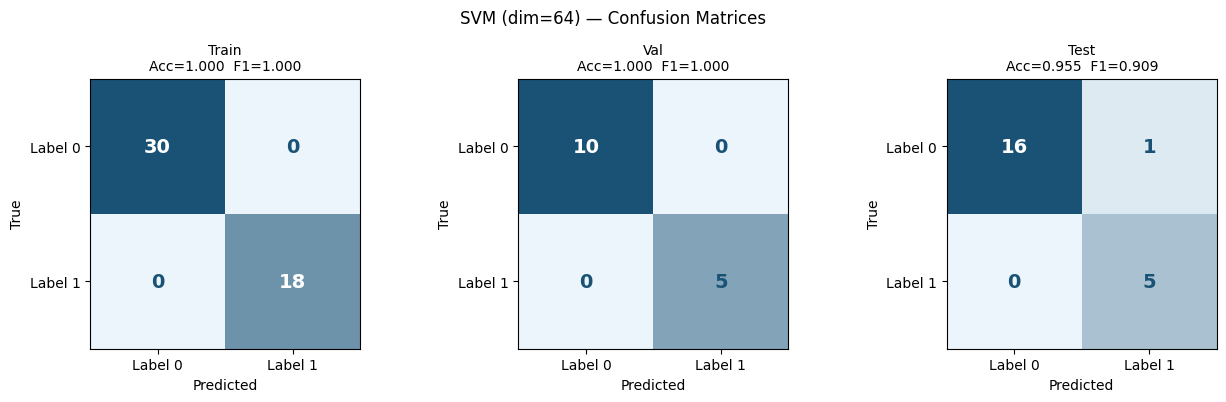


  ▶ Decision Tree GridSearchCV (24 combos)...
  DT: 24 combos × 5 folds = 120 fits


  Fitting DT:   0%|          | 00:00

  ✅ Done in 0.5s  Best CV F1=0.8732
  Best params: {'class_weight': 'balanced', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 5}

Decision Tree (dim=64) — Evaluation

── Train  AUROC=0.9917  F1(L1)=0.9412 ──
  Accuracy (combined): 0.9583
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 0.8889
                    precision    recall  f1-score   support

 Label 0 (healthy)       0.94      1.00      0.97        30
Label 1 (hospital)       1.00      0.89      0.94        18

          accuracy                           0.96        48
         macro avg       0.97      0.94      0.95        48
      weighted avg       0.96      0.96      0.96        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          30        0
  True 1           2       16

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support



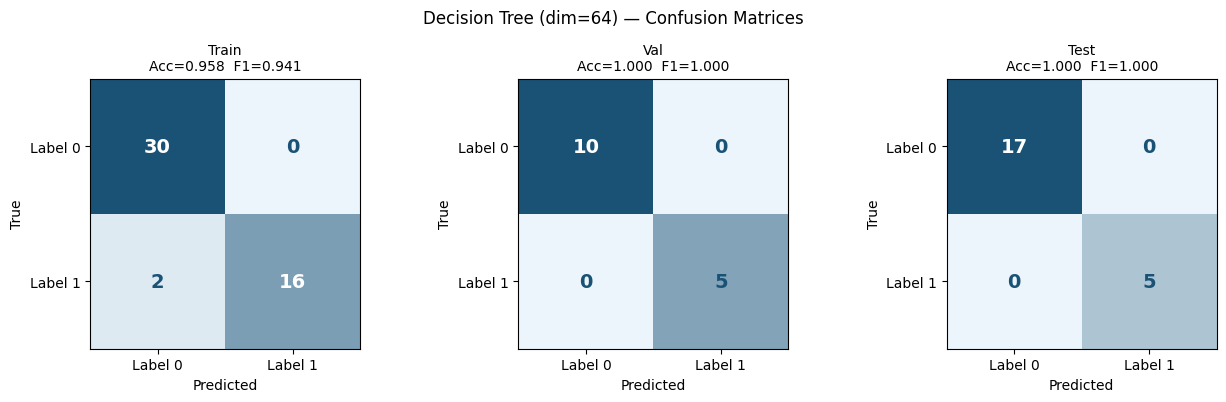


  ▶ PCA + XGBoost GridSearchCV (128 combos)...
  PCA+XGB: 128 combos × 5 folds = 640 fits


  Fitting PCA+XGB:   0%|          | 00:00

  ✅ Done in 13.9s  Best CV F1=0.8332
  Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__min_child_weight': 5, 'clf__n_estimators': 100, 'clf__reg_alpha': 0.5, 'clf__reg_lambda': 10, 'pca__n_components': 10}

PCA+XGBoost (dim=64) — Evaluation

── Train  AUROC=0.9833  F1(L1)=0.9231 ──
  Accuracy (combined): 0.9375
  Accuracy (label 0) : 0.9000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      0.90      0.95        30
Label 1 (hospital)       0.86      1.00      0.92        18

          accuracy                           0.94        48
         macro avg       0.93      0.95      0.94        48
      weighted avg       0.95      0.94      0.94        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          27        3
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
   

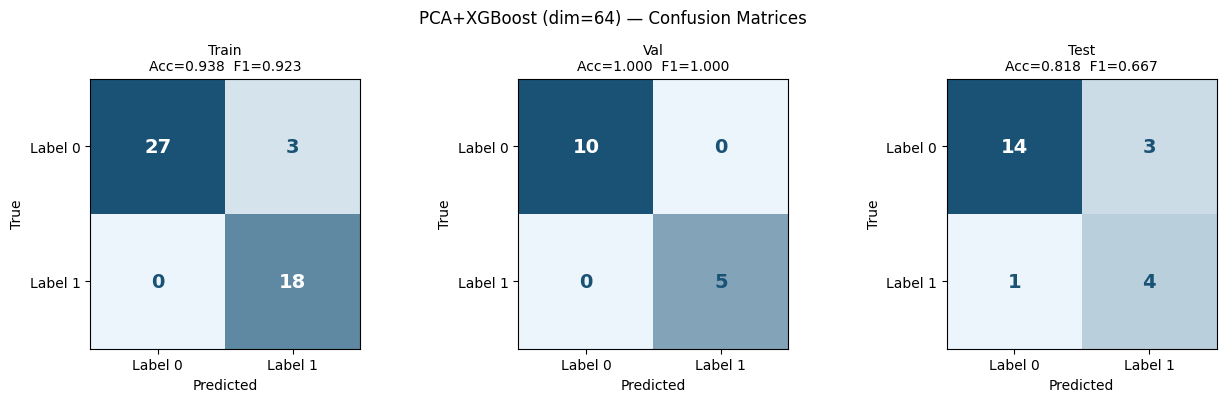

  ✅ Models captured for dim=64 → Step 5 can now save them

  ▶ Leave-One-Patient-Out CV...


  LOGO-CV:   0%|          | 0/6 [00:00<?, ?it/s]

  XGBoost          LOGO F1: 0.3176 ± 0.4656  min=0.000  max=1.000  (11.9s)
  LR               LOGO F1: 0.3176 ± 0.4656  min=0.000  max=1.000  (0.7s)
  RF               LOGO F1: 0.3176 ± 0.4656  min=0.000  max=1.000  (51.1s)
  SVM              LOGO F1: 0.2941 ± 0.4556  min=0.000  max=1.000  (1.0s)
  DT               LOGO F1: 0.2941 ± 0.4556  min=0.000  max=1.000  (0.5s)
  PCA+XGBoost      LOGO F1: 0.2588 ± 0.4380  min=0.000  max=1.000  (2.5s)

  ACCURACY TABLE — dim=64  Train
Metric                  LR         SVM          DT          RF     XGBoost PCA+XGBoost
-----------------------------------------------------------------
Accuracy            1.0000      1.0000      0.9583      0.9167      0.9792      0.9375
Acc L0              1.0000      1.0000      1.0000      0.8667      0.9667      0.9000
Acc L1              1.0000      1.0000      0.8889      1.0000      1.0000      1.0000
F1 (L1)             1.0000      1.0000      0.9412      0.9000      0.9730      0.9231
AUROC              

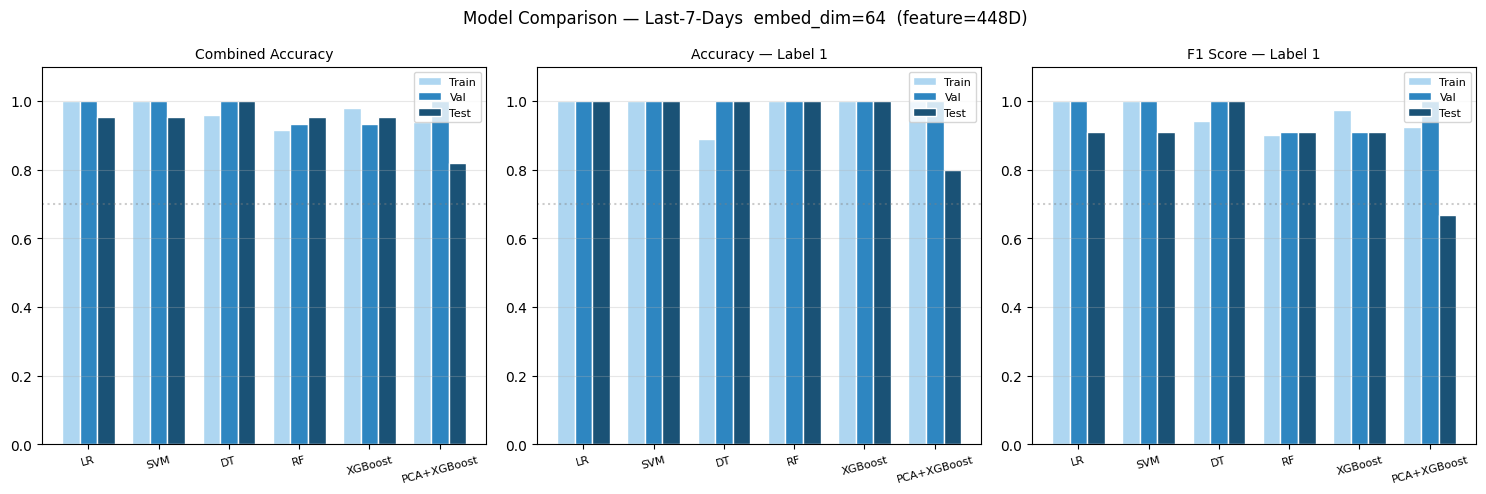


  ✅ Best model (dim=64) by val F1: LR
     Val F1=1.0000  LOGO F1=0.3176  Total time: 8.2 min

██████████████████████████████████████████████████████████████████████
  EMBED_DIM = 128  →  feature vector = 896 dims (128×7)
██████████████████████████████████████████████████████████████████████
  Loaded: train=(325, 131)  val=(100, 131)  test=(151, 131)
  Feature vector: 896 dims (128×7)
  Train: (48, 896)  Val: (15, 896)  Test: (22, 896)
  Label1 — train=18  val=5  test=5
  ✅ No patient leakage

  ▶ XGBoost Stage 1 — RandomizedSearchCV (100 iters)...
  XGB-Random: 100 combos × 5 folds = 500 fits


  Fitting XGB-Random:   0%|          | 00:00

  ✅ Done in 52.8s  Best CV F1=0.7166
  Best params: {'colsample_bytree': np.float64(0.747906403395441), 'gamma': np.float64(1.7167176096274397), 'learning_rate': np.float64(0.037595890520188475), 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 196, 'reg_alpha': np.float64(1.0459979618751882), 'reg_lambda': np.float64(2.4426482663713114), 'subsample': np.float64(0.970261632244802)}

  ▶ XGBoost Stage 2 — GridSearchCV (fine, ~512 combos)...
  XGB-Fine: 512 combos × 5 folds = 2560 fits


  Fitting XGB-Fine:   0%|          | 00:00

  ✅ Done in 125.4s  Best CV F1=0.2000
  Best params: {'colsample_bytree': 0.5, 'gamma': 0.5, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 100, 'reg_alpha': 1.0, 'reg_lambda': 8, 'subsample': 0.7}
  Using: random XGBoost

XGBoost (dim=128) — Evaluation

── Train  AUROC=0.9815  F1(L1)=0.8889 ──
  Accuracy (combined): 0.9167
  Accuracy (label 0) : 0.9333
  Accuracy (label 1) : 0.8889
                    precision    recall  f1-score   support

 Label 0 (healthy)       0.93      0.93      0.93        30
Label 1 (hospital)       0.89      0.89      0.89        18

          accuracy                           0.92        48
         macro avg       0.91      0.91      0.91        48
      weighted avg       0.92      0.92      0.92        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          28        2
  True 1           2       16

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accurac

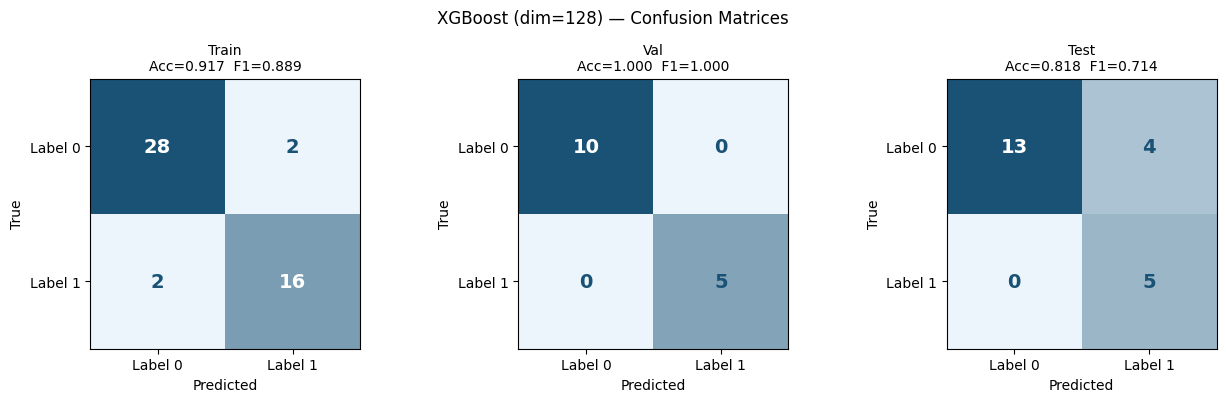


  ▶ Logistic Regression GridSearchCV (6 combos)...
  LR: 6 combos × 5 folds = 30 fits


  Fitting LR:   0%|          | 00:00

  ✅ Done in 0.4s  Best CV F1=0.6713
  Best params: {'clf__C': 0.001, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}

Logistic Regression (dim=128) — Evaluation

── Train  AUROC=0.8685  F1(L1)=0.7317 ──
  Accuracy (combined): 0.7708
  Accuracy (label 0) : 0.7333
  Accuracy (label 1) : 0.8333
                    precision    recall  f1-score   support

 Label 0 (healthy)       0.88      0.73      0.80        30
Label 1 (hospital)       0.65      0.83      0.73        18

          accuracy                           0.77        48
         macro avg       0.77      0.78      0.77        48
      weighted avg       0.79      0.77      0.77        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          22        8
  True 1           3       15

── Val  AUROC=0.9800  F1(L1)=0.7692 ──
  Accuracy (combined): 0.8000
  Accuracy (label 0) : 0.7000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      0.70  

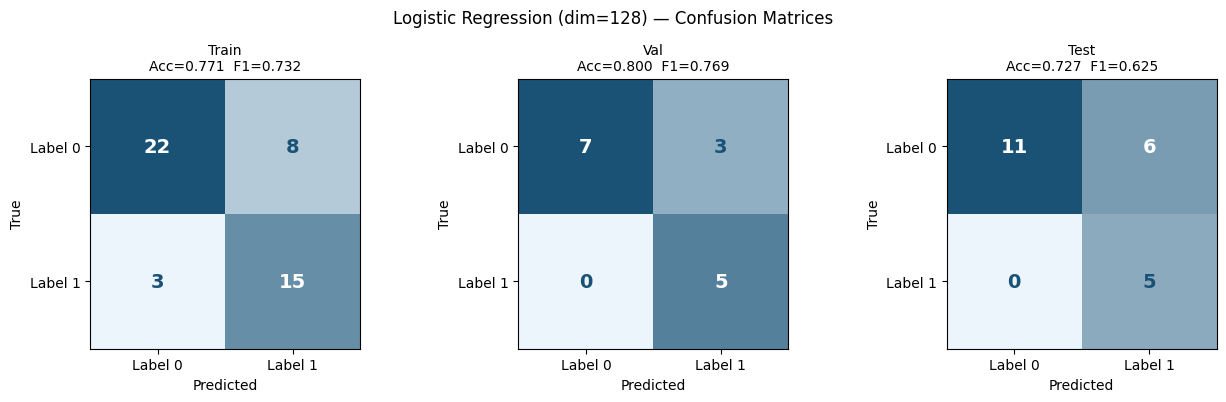


  ▶ Random Forest RandomizedSearchCV (100 iters)...
  RF-Random: 100 combos × 5 folds = 500 fits


  Fitting RF-Random:   0%|          | 00:00

  ✅ Done in 345.2s  Best CV F1=0.7486
  Best params: {'max_depth': None, 'max_features': 0.5, 'max_samples': np.float64(0.8477580432130638), 'min_samples_leaf': 5, 'min_samples_split': 8, 'n_estimators': 336}

Random Forest (dim=128) — Evaluation

── Train  AUROC=0.9796  F1(L1)=0.8235 ──
  Accuracy (combined): 0.8750
  Accuracy (label 0) : 0.9333
  Accuracy (label 1) : 0.7778
                    precision    recall  f1-score   support

 Label 0 (healthy)       0.88      0.93      0.90        30
Label 1 (hospital)       0.88      0.78      0.82        18

          accuracy                           0.88        48
         macro avg       0.88      0.86      0.86        48
      weighted avg       0.88      0.88      0.87        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          28        2
  True 1           4       14

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                  

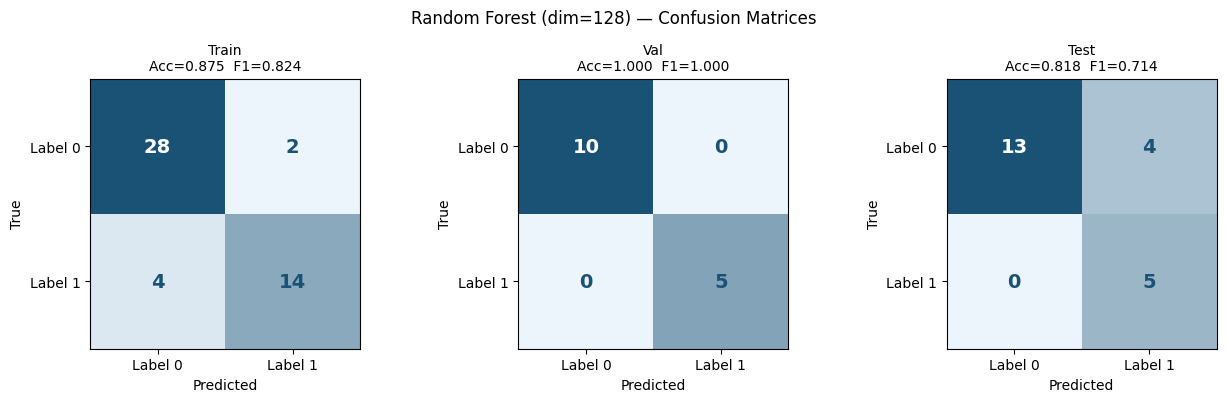


  ▶ SVM GridSearchCV (12 combos)...
  SVM: 12 combos × 5 folds = 60 fits


  Fitting SVM:   0%|          | 00:00

  ✅ Done in 1.0s  Best CV F1=0.7264
  Best params: {'clf__C': 10.0, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}

SVM (dim=128) — Evaluation

── Train  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00      1.00        30
Label 1 (hospital)       1.00      1.00      1.00        18

          accuracy                           1.00        48
         macro avg       1.00      1.00      1.00        48
      weighted avg       1.00      1.00      1.00        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          30        0
  True 1           0       18

── Val  AUROC=1.0000  F1(L1)=1.0000 ──
  Accuracy (combined): 1.0000
  Accuracy (label 0) : 1.0000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support

 Label 0 (healthy)       1.00      1.00      1.00        10


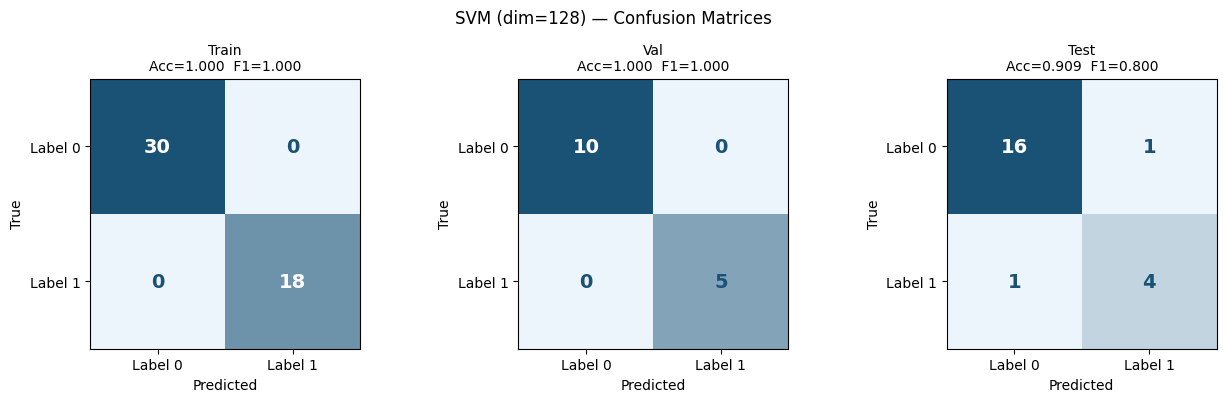


  ▶ Decision Tree GridSearchCV (24 combos)...
  DT: 24 combos × 5 folds = 120 fits


  Fitting DT:   0%|          | 00:00

  ✅ Done in 0.6s  Best CV F1=0.5889
  Best params: {'class_weight': 'balanced', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 5}

Decision Tree (dim=128) — Evaluation

── Train  AUROC=0.9611  F1(L1)=0.8718 ──
  Accuracy (combined): 0.8958
  Accuracy (label 0) : 0.8667
  Accuracy (label 1) : 0.9444
                    precision    recall  f1-score   support

 Label 0 (healthy)       0.96      0.87      0.91        30
Label 1 (hospital)       0.81      0.94      0.87        18

          accuracy                           0.90        48
         macro avg       0.89      0.91      0.89        48
      weighted avg       0.91      0.90      0.90        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          26        4
  True 1           1       17

── Val  AUROC=0.9900  F1(L1)=0.9091 ──
  Accuracy (combined): 0.9333
  Accuracy (label 0) : 0.9000
  Accuracy (label 1) : 1.0000
                    precision    recall  f1-score   support


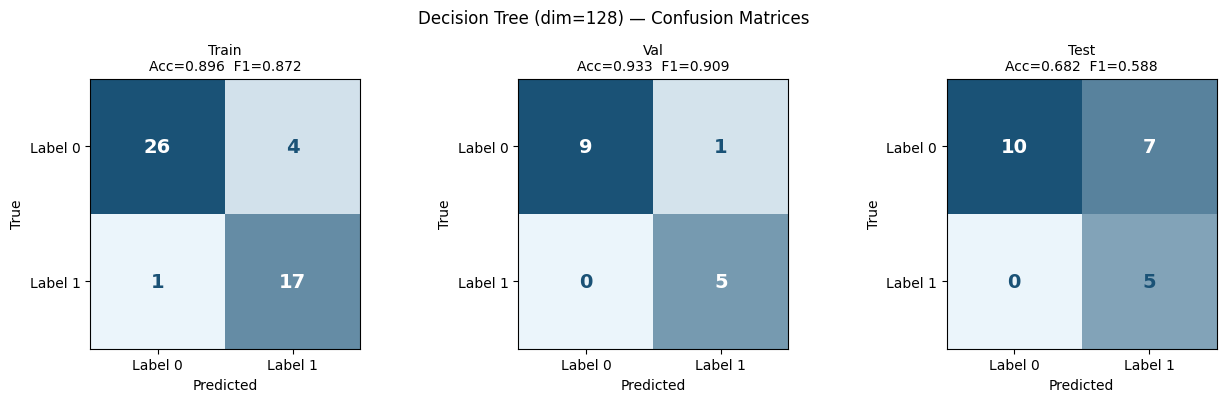


  ▶ PCA + XGBoost GridSearchCV (128 combos)...
  PCA+XGB: 128 combos × 5 folds = 640 fits


  Fitting PCA+XGB:   0%|          | 00:00

  ✅ Done in 15.8s  Best CV F1=0.6978
  Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__min_child_weight': 5, 'clf__n_estimators': 200, 'clf__reg_alpha': 0.5, 'clf__reg_lambda': 5, 'pca__n_components': 10}

PCA+XGBoost (dim=128) — Evaluation

── Train  AUROC=0.9787  F1(L1)=0.8421 ──
  Accuracy (combined): 0.8750
  Accuracy (label 0) : 0.8667
  Accuracy (label 1) : 0.8889
                    precision    recall  f1-score   support

 Label 0 (healthy)       0.93      0.87      0.90        30
Label 1 (hospital)       0.80      0.89      0.84        18

          accuracy                           0.88        48
         macro avg       0.86      0.88      0.87        48
      weighted avg       0.88      0.88      0.88        48

  Confusion matrix:
              Pred 0   Pred 1
  True 0          26        4
  True 1           2       16

── Val  AUROC=0.9600  F1(L1)=0.8333 ──
  Accuracy (combined): 0.8667
  Accuracy (label 0) : 0.8000
  Accuracy (label 1) : 1.0000
   

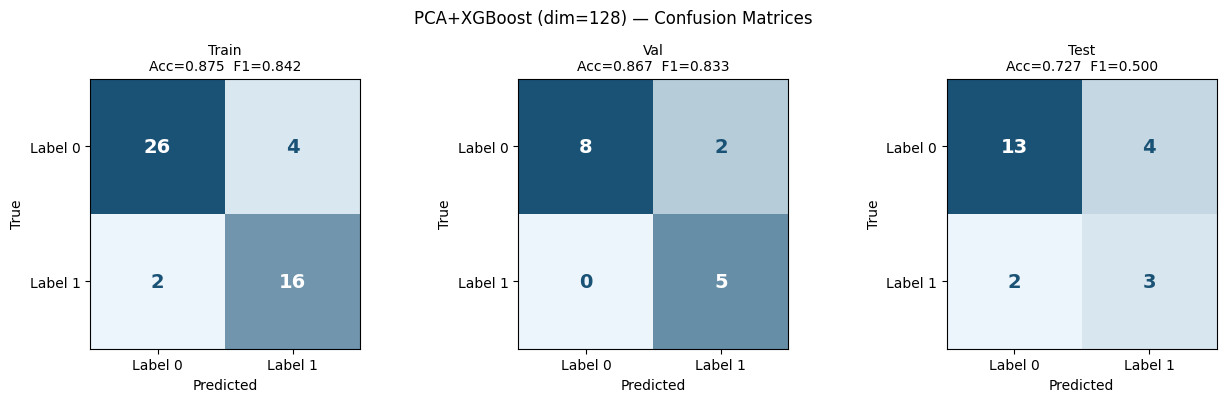

  ✅ Models captured for dim=128 → Step 5 can now save them

  ▶ Leave-One-Patient-Out CV...


  LOGO-CV:   0%|          | 0/6 [00:00<?, ?it/s]

  XGBoost          LOGO F1: 0.2118 ± 0.4086  min=0.000  max=1.000  (29.3s)
  LR               LOGO F1: 0.2824 ± 0.4501  min=0.000  max=1.000  (0.8s)
  RF               LOGO F1: 0.2000 ± 0.4000  min=0.000  max=1.000  (176.0s)
  SVM              LOGO F1: 0.2706 ± 0.4443  min=0.000  max=1.000  (5.6s)
  DT               LOGO F1: 0.2000 ± 0.4000  min=0.000  max=1.000  (0.4s)
  PCA+XGBoost      LOGO F1: 0.2471 ± 0.4313  min=0.000  max=1.000  (3.1s)

  ACCURACY TABLE — dim=128  Train
Metric                  LR         SVM          DT          RF     XGBoost PCA+XGBoost
-----------------------------------------------------------------
Accuracy            0.7708      1.0000      0.8958      0.8750      0.9167      0.8750
Acc L0              0.7333      1.0000      0.8667      0.9333      0.9333      0.8667
Acc L1              0.8333      1.0000      0.9444      0.7778      0.8889      0.8889
F1 (L1)             0.7317      1.0000      0.8718      0.8235      0.8889      0.8421
AUROC            

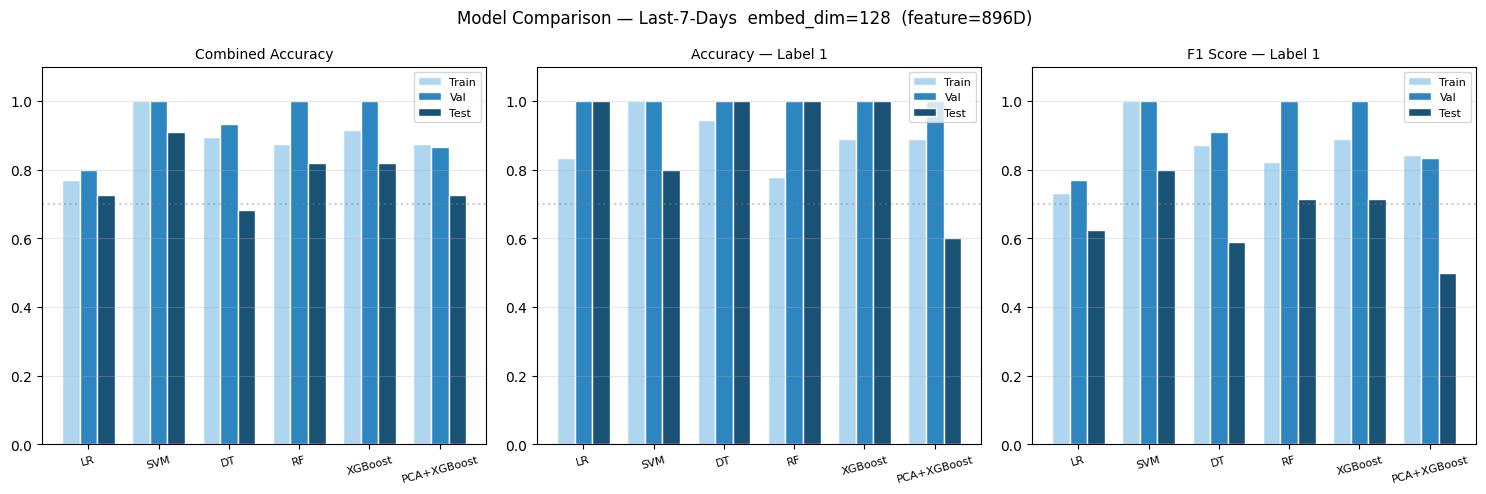


  ✅ Best model (dim=128) by val F1: SVM
     Val F1=1.0000  LOGO F1=0.2706  Total time: 12.8 min

FINAL CROSS-DIM COMPARISON — Last 7 Days
   Dim  Best Model         Val F1   LOGO F1      Time
-------------------------------------------------------
    32  SVM                1.0000    0.2353      7.7m
    64  LR                 1.0000    0.3176      8.2m
   128  SVM                1.0000    0.2706     12.8m


In [5]:
# ── Helper: timed GridSearch/RandomizedSearch with progress bar ─────────────
def fit_with_progress(search, X, y, label):
    """Fit a GridSearchCV or RandomizedSearchCV with a tqdm timer."""
    n_fits = (len(search.param_grid)
              if hasattr(search, 'param_grid')
              else search.n_iter)
    # Count actual combinations for GridSearchCV
    if hasattr(search, 'param_grid'):
        from itertools import product
        pg = search.param_grid
        n_fits = 1
        for v in pg.values(): n_fits *= len(v)
    n_fits_total = n_fits * search.cv if hasattr(search.cv, '__len__') else n_fits * 5
    print(f'  {label}: {n_fits} combos × 5 folds = {n_fits_total} fits')
    t0 = time.time()
    with tqdm(total=1, desc=f'  Fitting {label}', bar_format='{l_bar}{bar}| {elapsed}') as pbar:
        search.fit(X, y)
        pbar.update(1)
    elapsed = time.time() - t0
    print(f'  ✅ Done in {elapsed:.1f}s  Best CV F1={search.best_score_:.4f}')
    return search


# ── Main loop ─────────────────────────────────────────────────────────────────
# Dict to capture all trained estimators across dims for Step 5
all_trained_models = {}  # {embed_dim: {save_name: estimator}}

cross_dim_summary = {}
dim_pbar = tqdm(EMBED_DIMS, desc='Overall progress', unit='dim')

for EMBED_DIM in dim_pbar:
    dim_pbar.set_description(f'dim={EMBED_DIM}')
    print('\n' + '█'*70)
    print(f'  EMBED_DIM = {EMBED_DIM}  →  feature vector = {EMBED_DIM*7} dims ({EMBED_DIM}×7)')
    print('█'*70)
    dim_start = time.time()

    # ── Load embeddings ──────────────────────────────────────────────────────
    EMB_FOLDER = os.path.join(BASE_MODEL_DIR,
                     f'daily_embedding_classifier_last7days_{EMBED_DIM}dim')
    # Per-model save dirs inside 5models/last7days/{dim}dim/{model_name}/
    DIM_MODELS_DIR = os.path.join(MODELS_ROOT, f'{EMBED_DIM}dim')
    # OUT_DIR used for plots/csvs — store alongside embeddings
    OUT_DIR = os.path.join(DIM_MODELS_DIR, 'results')
    os.makedirs(OUT_DIR, exist_ok=True)

    emb_train = pd.read_parquet(os.path.join(EMB_FOLDER, 'emb_train.parquet'))
    emb_val   = pd.read_parquet(os.path.join(EMB_FOLDER, 'emb_val.parquet'))
    emb_test  = pd.read_parquet(os.path.join(EMB_FOLDER, 'emb_test.parquet'))

    EMB_COLS = [c for c in emb_train.columns if c.startswith('emb_')]
    print(f'  Loaded: train={emb_train.shape}  val={emb_val.shape}  test={emb_test.shape}')
    print(f'  Feature vector: {len(EMB_COLS)*7} dims ({len(EMB_COLS)}×7)')

    # ── Build patient-level features ─────────────────────────────────────────
    X_tr, y_tr, pids_tr = build_patient_features(emb_train, EMB_COLS, EMBED_DIM)
    X_va, y_va, pids_va = build_patient_features(emb_val,   EMB_COLS, EMBED_DIM)
    X_te, y_te, pids_te = build_patient_features(emb_test,  EMB_COLS, EMBED_DIM)
    X_tv = np.vstack([X_tr, X_va])
    y_tv = np.concatenate([y_tr, y_va])

    print(f'  Train: {X_tr.shape}  Val: {X_va.shape}  Test: {X_te.shape}')
    print(f'  Label1 — train={y_tr.sum()}  val={y_va.sum()}  test={y_te.sum()}')
    assert len(set(pids_tr) & set(pids_va)) == 0, 'Train/Val overlap!'
    assert len(set(pids_tr) & set(pids_te)) == 0, 'Train/Test overlap!'
    assert len(set(pids_va) & set(pids_te)) == 0, 'Val/Test overlap!'
    print('  ✅ No patient leakage')

    scale_pos = (y_tv == 0).sum() / max((y_tv == 1).sum(), 1)

    # ── XGBoost Stage 1: RandomizedSearchCV (100 iters) ──────────────────────
    print('\n  ▶ XGBoost Stage 1 — RandomizedSearchCV (100 iters)...')
    xgb_rand_grid = {
        'n_estimators':     randint(50, 400),
        'max_depth':        randint(2, 5),
        'learning_rate':    uniform(0.005, 0.1),
        'subsample':        uniform(0.5, 0.5),
        'colsample_bytree': uniform(0.4, 0.5),
        'reg_alpha':        uniform(0.0, 3.0),
        'reg_lambda':       uniform(1.0, 15.0),
        'min_child_weight': randint(3, 25),
        'gamma':            uniform(0.0, 2.0),
    }
    xgb_rand = fit_with_progress(
        RandomizedSearchCV(
            xgb.XGBClassifier(scale_pos_weight=scale_pos, eval_metric='logloss',
                               random_state=42, verbosity=0),
            xgb_rand_grid, n_iter=100, cv=CV, scoring=f1_scorer,
            n_jobs=-1, refit=True, random_state=42, verbose=0),
        X_tv, y_tv, 'XGB-Random')
    print(f'  Best params: {xgb_rand.best_params_}')

    # ── XGBoost Stage 2: fine GridSearchCV (~512 combos) ─────────────────────
    print('\n  ▶ XGBoost Stage 2 — GridSearchCV (fine, ~512 combos)...')
    xgb_fine_grid = {
        'n_estimators':     [100, 200],     # 2
        'max_depth':        [2, 3],         # 2
        'learning_rate':    [0.01, 0.02],   # 2
        'min_child_weight': [10, 15],       # 2
        'gamma':            [0.5, 1.0],     # 2
        'subsample':        [0.7, 0.8],     # 2
        'colsample_bytree': [0.5, 0.6],     # 2
        'reg_alpha':        [1.0, 2.0],     # 2
        'reg_lambda':       [8, 15],        # 2
    }  # 2^9 = 512 combos × 5 = 2560 fits
    xgb_fine = fit_with_progress(
        GridSearchCV(
            xgb.XGBClassifier(scale_pos_weight=scale_pos, eval_metric='logloss',
                               random_state=42, verbosity=0),
            xgb_fine_grid, cv=CV, scoring=f1_scorer,
            n_jobs=-1, refit=True, verbose=0),
        X_tv, y_tv, 'XGB-Fine')
    print(f'  Best params: {xgb_fine.best_params_}')
    best_xgb = (xgb_fine.best_estimator_
                if xgb_fine.best_score_ >= xgb_rand.best_score_
                else xgb_rand.best_estimator_)
    print(f'  Using: {"fine" if xgb_fine.best_score_ >= xgb_rand.best_score_ else "random"} XGBoost')
    xgb_metrics = evaluate(best_xgb, f'XGBoost (dim={EMBED_DIM})', 'xgboost', OUT_DIR,
                           X_tr, y_tr, pids_tr, X_va, y_va, pids_va, X_te, y_te, pids_te)

    # ── Logistic Regression (6 combos) ───────────────────────────────────────
    print('\n  ▶ Logistic Regression GridSearchCV (6 combos)...')
    lr_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced',
                                    max_iter=2000, random_state=42))
    ])
    lr_grid = {
        'clf__C':       [0.001, 0.01, 0.1],   # 3
        'clf__penalty': ['l2'],
        'clf__solver':  ['lbfgs', 'liblinear'],# 2  → 6 combos
    }
    lr_gs = fit_with_progress(
        GridSearchCV(lr_pipe, lr_grid, cv=CV, scoring=f1_scorer,
                     n_jobs=-1, refit=True, verbose=0),
        X_tv, y_tv, 'LR')
    print(f'  Best params: {lr_gs.best_params_}')
    lr_metrics = evaluate(lr_gs, f'Logistic Regression (dim={EMBED_DIM})',
                          'logistic_regression', OUT_DIR,
                          X_tr, y_tr, pids_tr, X_va, y_va, pids_va, X_te, y_te, pids_te)

    # ── Random Forest — RandomizedSearchCV (100 iters) ────────────────────────
    print('\n  ▶ Random Forest RandomizedSearchCV (100 iters)...')
    rf_rand_grid = {
        'n_estimators':      randint(100, 500),
        'max_depth':         [3, 4, 5, 6, None],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf':  randint(1, 15),
        'max_features':      ['sqrt', 'log2', 0.3, 0.5],
        'max_samples':       uniform(0.5, 0.5),
    }
    rf_rand = fit_with_progress(
        RandomizedSearchCV(
            RandomForestClassifier(class_weight='balanced',
                                    random_state=42, n_jobs=-1),
            rf_rand_grid, n_iter=100, cv=CV, scoring=f1_scorer,
            n_jobs=-1, refit=True, random_state=42, verbose=0),
        X_tv, y_tv, 'RF-Random')
    print(f'  Best params: {rf_rand.best_params_}')
    rf_metrics = evaluate(rf_rand, f'Random Forest (dim={EMBED_DIM})',
                          'random_forest', OUT_DIR,
                          X_tr, y_tr, pids_tr, X_va, y_va, pids_va, X_te, y_te, pids_te)

    # ── SVM (12 combos) ───────────────────────────────────────────────────────
    print('\n  ▶ SVM GridSearchCV (12 combos)...')
    svm_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(class_weight='balanced', probability=True, random_state=42))
    ])
    svm_grid = {
        'clf__C':      [0.1, 1.0, 10.0],    # 3
        'clf__kernel': ['rbf', 'linear'],    # 2
        'clf__gamma':  ['scale', 'auto'],    # 2  → 12 combos
    }
    svm_gs = fit_with_progress(
        GridSearchCV(svm_pipe, svm_grid, cv=CV, scoring=f1_scorer,
                     n_jobs=-1, refit=True, verbose=0),
        X_tv, y_tv, 'SVM')
    print(f'  Best params: {svm_gs.best_params_}')
    svm_metrics = evaluate(svm_gs, f'SVM (dim={EMBED_DIM})', 'svm', OUT_DIR,
                           X_tr, y_tr, pids_tr, X_va, y_va, pids_va, X_te, y_te, pids_te)

    # ── Decision Tree (24 combos) ─────────────────────────────────────────────
    print('\n  ▶ Decision Tree GridSearchCV (24 combos)...')
    dt_grid = {
        'max_depth':         [3, 5, None],       # 3
        'min_samples_split': [5, 10],             # 2
        'min_samples_leaf':  [3, 5],              # 2
        'max_features':      ['sqrt', 'log2'],    # 2  → 24 combos
        'class_weight':      ['balanced'],
    }
    dt_gs = fit_with_progress(
        GridSearchCV(
            DecisionTreeClassifier(random_state=42),
            dt_grid, cv=CV, scoring=f1_scorer,
            n_jobs=-1, refit=True, verbose=0),
        X_tv, y_tv, 'DT')
    print(f'  Best params: {dt_gs.best_params_}')
    dt_metrics = evaluate(dt_gs, f'Decision Tree (dim={EMBED_DIM})',
                          'decision_tree', OUT_DIR,
                          X_tr, y_tr, pids_tr, X_va, y_va, pids_va, X_te, y_te, pids_te)

    # ── PCA + XGBoost (128 combos) ────────────────────────────────────────────
    print('\n  ▶ PCA + XGBoost GridSearchCV (128 combos)...')
    max_pca = min(30, X_tv.shape[0] - 1, X_tv.shape[1])
    pca_candidates = [c for c in [10, 20] if c <= max_pca]  # 2
    pca_xgb_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(random_state=42)),
        ('clf',    xgb.XGBClassifier(scale_pos_weight=scale_pos,
                                      eval_metric='logloss',
                                      random_state=42, verbosity=0))
    ])
    pca_xgb_grid = {
        'pca__n_components':     pca_candidates,       # 2
        'clf__n_estimators':     [100, 200],            # 2
        'clf__max_depth':        [2, 3],                # 2
        'clf__learning_rate':    [0.01, 0.05],          # 2
        'clf__min_child_weight': [5, 10],               # 2
        'clf__reg_alpha':        [0.5, 2.0],            # 2
        'clf__reg_lambda':       [5, 10],               # 2
    }  # 2^7 = 128 combos × 5 = 640 fits
    pca_xgb_gs = fit_with_progress(
        GridSearchCV(pca_xgb_pipe, pca_xgb_grid, cv=CV, scoring=f1_scorer,
                     n_jobs=-1, refit=True, verbose=0),
        X_tv, y_tv, 'PCA+XGB')
    print(f'  Best params: {pca_xgb_gs.best_params_}')
    pca_xgb_metrics = evaluate(pca_xgb_gs, f'PCA+XGBoost (dim={EMBED_DIM})',
                                'pca_xgboost', OUT_DIR,
                                X_tr, y_tr, pids_tr, X_va, y_va, pids_va, X_te, y_te, pids_te)

    # ── Capture trained models for Step 5 saving ───────────────────────────────
    all_trained_models[EMBED_DIM] = {
        'xgboost':              {'clf': best_xgb,    'save_dir': os.path.join(DIM_MODELS_DIR, 'xgboost')},
        'logistic_regression':  {'clf': lr_gs,       'save_dir': os.path.join(DIM_MODELS_DIR, 'logistic_regression')},
        'random_forest':        {'clf': rf_rand,     'save_dir': os.path.join(DIM_MODELS_DIR, 'random_forest')},
        'svm':                  {'clf': svm_gs,      'save_dir': os.path.join(DIM_MODELS_DIR, 'svm')},
        'decision_tree':        {'clf': dt_gs,       'save_dir': os.path.join(DIM_MODELS_DIR, 'decision_tree')},
        'pca_xgboost':          {'clf': pca_xgb_gs, 'save_dir': os.path.join(DIM_MODELS_DIR, 'pca_xgboost')},
    }
    print(f'  ✅ Models captured for dim={EMBED_DIM} → Step 5 can now save them')

    # ── LOGO-CV with progress bar ─────────────────────────────────────────────
    print('\n  ▶ Leave-One-Patient-Out CV...')
    X_all_pat = np.vstack([X_tr, X_va, X_te])
    y_all_pat = np.concatenate([y_tr, y_va, y_te])
    pids_all  = np.concatenate([pids_tr, pids_va, pids_te])
    logo      = LeaveOneGroupOut()

    logo_results = {}
    logo_models = [
        ('XGBoost',     best_xgb),
        ('LR',          lr_gs.best_estimator_),
        ('RF',          rf_rand.best_estimator_),
        ('SVM',         svm_gs.best_estimator_),
        ('DT',          dt_gs.best_estimator_),
        ('PCA+XGBoost', pca_xgb_gs.best_estimator_),
    ]
    for model_name, clf in tqdm(logo_models, desc='  LOGO-CV', leave=False):
        t0 = time.time()
        scores = cross_val_score(
            clf, X_all_pat, y_all_pat,
            cv=logo, groups=pids_all,
            scoring=f1_scorer, n_jobs=-1)
        elapsed = time.time() - t0
        logo_results[model_name] = scores.mean()
        print(f'  {model_name:<15}  LOGO F1: '
              f'{scores.mean():.4f} ± {scores.std():.4f}  '
              f'min={scores.min():.3f}  max={scores.max():.3f}  '
              f'({elapsed:.1f}s)')

    # ── Summary table ─────────────────────────────────────────────────────────
    all_models = [
        ('LR',          lr_metrics),
        ('SVM',         svm_metrics),
        ('DT',          dt_metrics),
        ('RF',          rf_metrics),
        ('XGBoost',     xgb_metrics),
        ('PCA+XGBoost', pca_xgb_metrics),
    ]

    for split_name in ['Train', 'Val', 'Test']:
        print(f'\n{"="*65}')
        print(f'  ACCURACY TABLE — dim={EMBED_DIM}  {split_name}')
        print(f'{"="*65}')
        header = f'{"Metric":<14}' + ''.join(f'{n:>12}' for n, _ in all_models)
        print(header)
        print('-'*65)
        for row_label, key in [
            ('Accuracy',   'acc'),
            ('Acc L0',     'acc0'),
            ('Acc L1',     'acc1'),
            ('F1 (L1)',    'f1'),
            ('AUROC',      'auc'),
        ]:
            row = f'{row_label:<14}'
            for _, m in all_models:
                val = m[split_name].get(key, float('nan'))
                row += f'{val:>12.4f}'
            print(row)

    # Summary DataFrame + CSV
    summary_rows = []
    for mname, m in all_models:
        for split in ['Train', 'Val', 'Test']:
            summary_rows.append({
                'embed_dim': EMBED_DIM,
                'model':     mname,
                'split':     split,
                'acc':       m[split]['acc'],
                'acc_L0':    m[split]['acc0'],
                'acc_L1':    m[split]['acc1'],
                'f1_L1':     m[split]['f1'],
                'auroc':     m[split]['auc'],
                'logo_f1':   logo_results.get(mname, float('nan')),
            })
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(os.path.join(OUT_DIR, f'summary_{EMBED_DIM}dim.csv'), index=False)

    # Bar chart
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Model Comparison — Last-7-Days  embed_dim={EMBED_DIM}  '
                 f'(feature={EMBED_DIM*7}D)', fontsize=12)
    model_names = [n for n, _ in all_models]
    x = np.arange(len(model_names))
    w = 0.25
    colors = ['#AED6F1', '#2E86C1', '#1A5276']
    for ax, metric, title in [
        (axes[0], 'acc',    'Combined Accuracy'),
        (axes[1], 'acc_L1', 'Accuracy — Label 1'),
        (axes[2], 'f1_L1',  'F1 Score — Label 1'),
    ]:
        for i, (split, color) in enumerate(zip(['Train','Val','Test'], colors)):
            vals = [summary_df[(summary_df['model']==m) &
                               (summary_df['split']==split)][metric].values[0]
                    for m in model_names]
            ax.bar(x + (i-1)*w, vals, w, label=split, color=color, edgecolor='white')
        ax.set_title(title, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, fontsize=8, rotation=15)
        ax.set_ylim(0, 1.1)
        ax.axhline(0.7, color='gray', linestyle=':', alpha=0.4)
        ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f'model_comparison_{EMBED_DIM}dim.png'), dpi=150)
    plt.show()

    dim_elapsed = time.time() - dim_start
    best_row = (summary_df[summary_df['split']=='Val']
                .sort_values('f1_L1', ascending=False).iloc[0])
    print(f'\n  ✅ Best model (dim={EMBED_DIM}) by val F1: {best_row["model"]}')
    print(f'     Val F1={best_row["f1_L1"]:.4f}  '
          f'LOGO F1={logo_results.get(best_row["model"], float("nan")):.4f}  '
          f'Total time: {dim_elapsed/60:.1f} min')

    cross_dim_summary[EMBED_DIM] = {
        'best_model': best_row['model'],
        'val_f1':     best_row['f1_L1'],
        'logo_f1':    logo_results.get(best_row['model'], float('nan')),
        'time_min':   round(dim_elapsed/60, 1),
        'summary_df': summary_df,
        'out_dir':    OUT_DIR,
        'dim_models_dir': DIM_MODELS_DIR,
    }

# ── Final cross-dim comparison ────────────────────────────────────────────────
print('\n' + '='*70)
print('FINAL CROSS-DIM COMPARISON — Last 7 Days')
print('='*70)
print(f'{"Dim":>6}  {"Best Model":<15}  {"Val F1":>8}  {"LOGO F1":>8}  {"Time":>8}')
print('-'*55)
for dim, res in cross_dim_summary.items():
    print(f'{dim:>6}  {res["best_model"]:<15}  '
          f'{res["val_f1"]:>8.4f}  {res["logo_f1"]:>8.4f}  '
          f'{res["time_min"]:>7.1f}m')


---
## Step 5 — Save All 18 Trained Models

Run immediately after Step 4 (same session — models live in memory).
Saves each model to its own subfolder with:
- `model.joblib` — the trained estimator
- `best_params.json` — best hyperparameters found
- `metrics.json` — train / val / test accuracy, F1, AUROC

**Folder structure:**
```
5models/last7days/
  32dim/
    xgboost/            model.joblib  best_params.json  metrics.json
    logistic_regression/
    random_forest/
    svm/
    decision_tree/
    pca_xgboost/
  64dim/  ...
  128dim/ ...
```

**To reload later (no re-training):**
```python
import joblib
model = joblib.load('.../5models/last7days/32dim/xgboost/model.joblib')
preds = model.predict(X_te)
probs = model.predict_proba(X_te)[:, 1]
```


In [6]:
import joblib, json as _json

MODEL_LABELS = {
    'xgboost':             'XGBoost',
    'logistic_regression': 'Logistic Regression',
    'random_forest':       'Random Forest',
    'svm':                 'SVM',
    'decision_tree':       'Decision Tree',
    'pca_xgboost':         'PCA + XGBoost',
}

total_saved = 0
save_errors = []
n_total     = len(EMBED_DIMS) * len(MODEL_LABELS)  # 18

print('Saving trained models...')
print(f'Target: {n_total} models  ({len(EMBED_DIMS)} dims × {len(MODEL_LABELS)} models)')
print('='*65)

for EMBED_DIM in EMBED_DIMS:
    if EMBED_DIM not in all_trained_models:
        print(f'\n  ⚠️  dim={EMBED_DIM} not in all_trained_models — skipping')
        continue

    print(f'\n  ── dim={EMBED_DIM} ──────────────────────────────────────────')

    # Retrieve metrics from cross_dim_summary for this dim
    summary_df = cross_dim_summary[EMBED_DIM]['summary_df']

    for save_name, entry in all_trained_models[EMBED_DIM].items():
        clf      = entry['clf']
        save_dir = entry['save_dir']
        label    = MODEL_LABELS.get(save_name, save_name)
        os.makedirs(save_dir, exist_ok=True)

        try:
            # 1) Save model
            model_path = os.path.join(save_dir, 'model.joblib')
            joblib.dump(clf, model_path, compress=3)
            size_kb = os.path.getsize(model_path) / 1024

            # 2) Save best hyperparameters
            params = {}
            if hasattr(clf, 'best_params_'):
                params = {str(k): str(v) for k, v in clf.best_params_.items()}
            elif hasattr(clf, 'get_params'):
                params = {str(k): str(v) for k, v in clf.get_params().items()}
            with open(os.path.join(save_dir, 'best_params.json'), 'w') as f:
                _json.dump(params, f, indent=2)

            # 3) Save metrics (train/val/test)
            # Map save_name → summary_df model name
            name_map = {
                'xgboost':             'XGBoost',
                'logistic_regression': 'LR',
                'random_forest':       'RF',
                'svm':                 'SVM',
                'decision_tree':       'DT',
                'pca_xgboost':         'PCA+XGBoost',
            }
            mname  = name_map.get(save_name, save_name)
            m_rows = summary_df[summary_df['model'] == mname]
            metrics_out = {}
            for _, row in m_rows.iterrows():
                metrics_out[row['split']] = {
                    'accuracy':  round(float(row['acc']),    4),
                    'acc_L0':    round(float(row['acc_L0']), 4),
                    'acc_L1':    round(float(row['acc_L1']), 4),
                    'f1_L1':     round(float(row['f1_L1']),  4),
                    'auroc':     round(float(row['auroc']),  4),
                    'logo_f1':   round(float(row['logo_f1']),4),
                }
            with open(os.path.join(save_dir, 'metrics.json'), 'w') as f:
                _json.dump(metrics_out, f, indent=2)

            print(f'    ✅  {label:<25}  model.joblib ({size_kb:.0f} KB)')
            total_saved += 1

        except Exception as e:
            print(f'    ❌  {label}: {e}')
            save_errors.append((EMBED_DIM, save_name, str(e)))

# ── Summary ───────────────────────────────────────────────────────────────────
print(f'\n{"="*65}')
print(f'✅  Saved : {total_saved} / {n_total} models')
if save_errors:
    print(f'❌  Errors: {save_errors}')
else:
    print('   No errors.')

# ── Verify folder structure on disk ──────────────────────────────────────────
print(f'\nFolder structure ({MODELS_ROOT}):')
for dim in EMBED_DIMS:
    dim_dir = os.path.join(MODELS_ROOT, f'{dim}dim')
    print(f'  {dim}dim/')
    for mname in MODEL_NAMES:
        mdir   = os.path.join(dim_dir, mname)
        files  = os.listdir(mdir) if os.path.exists(mdir) else []
        status = '✅' if 'model.joblib' in files else '❌'
        size_kb = (os.path.getsize(os.path.join(mdir,'model.joblib'))/1024
                   if 'model.joblib' in files else 0)
        print(f'    {status}  {mname:<25} {sorted(files)}  ({size_kb:.0f} KB)')


Saving trained models...
Target: 18 models  (3 dims × 6 models)

  ── dim=32 ──────────────────────────────────────────
    ✅  XGBoost                    model.joblib (8 KB)
    ✅  Logistic Regression        model.joblib (9 KB)
    ✅  Random Forest              model.joblib (81 KB)
    ✅  SVM                        model.joblib (47 KB)
    ✅  Decision Tree              model.joblib (3 KB)
    ✅  PCA + XGBoost              model.joblib (28 KB)

  ── dim=64 ──────────────────────────────────────────
    ✅  XGBoost                    model.joblib (8 KB)
    ✅  Logistic Regression        model.joblib (15 KB)
    ✅  Random Forest              model.joblib (33 KB)
    ✅  SVM                        model.joblib (37 KB)
    ✅  Decision Tree              model.joblib (3 KB)
    ✅  PCA + XGBoost              model.joblib (41 KB)

  ── dim=128 ──────────────────────────────────────────
    ✅  XGBoost                    model.joblib (11 KB)
    ✅  Logistic Regression        model.joblib (28 KB)
  